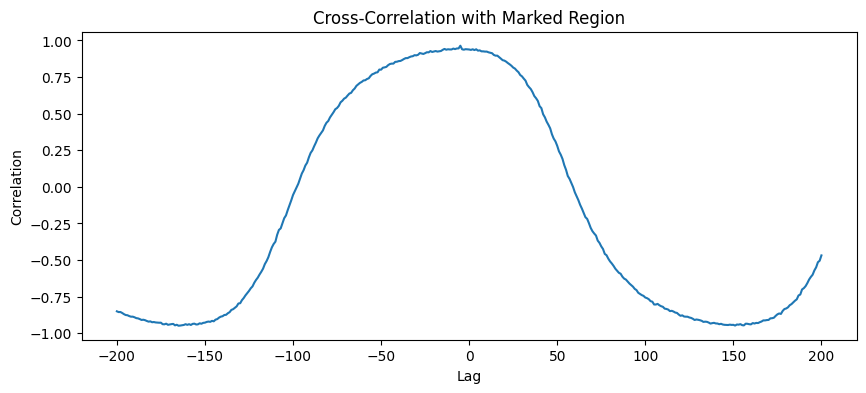

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Example signals
np.random.seed(0)
t = np.arange(1000)
x = np.sin(0.02*t) + 0.1*np.random.randn(1000)  # potential cause
y = np.roll(x, 5) + 0.2*np.random.randn(1000)   # effect (shifted)

# Marked region in y
start, end = 400, 600
marked_region = y[start:end]

# Cross-correlation with lags
window_size = len(marked_region)
lags = np.arange(-200, 201)  # test +/- 200 samples
corrs = []

for lag in lags:
    if lag < 0:
        segment_x = x[start+lag:end+lag]
    else:
        segment_x = x[start+lag:end+lag]
    if len(segment_x) == len(marked_region):
        corr = np.corrcoef(segment_x, marked_region)[0, 1]
        corrs.append(corr)
    else:
        corrs.append(np.nan)

plt.figure(figsize=(10,4))
plt.plot(lags, corrs)
plt.title("Cross-Correlation with Marked Region")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()


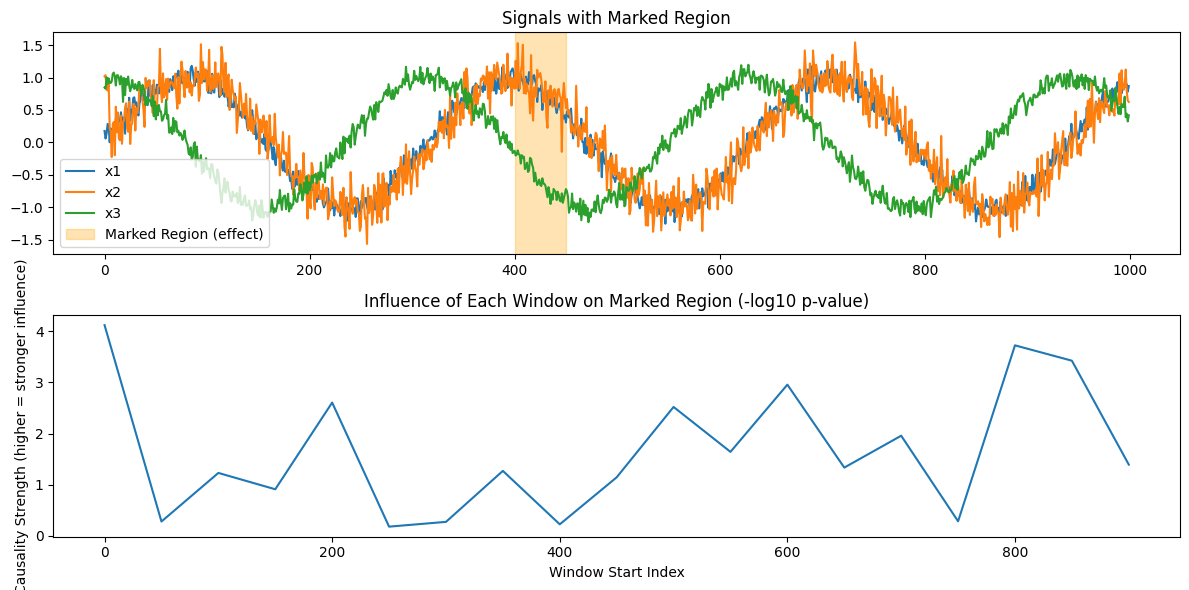

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.api import VAR

# Synthetic data: 3 regions (A, B, C) influence each other
np.random.seed(0)
t = np.arange(1000)
x1 = np.sin(0.02*t) + 0.1*np.random.randn(1000)      # base signal
x2 = np.roll(x1, 5) + 0.2*np.random.randn(1000)      # influenced by x1
x3 = np.cos(0.02*t) + 0.1*np.random.randn(1000)      # independent signal

# Stack signals into DataFrame for VAR
df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})

# Marked region: effect we want to explain
effect_start, effect_end = 400, 450
marked_region = df['x2'][effect_start:effect_end]

window_size = len(marked_region)
step = 50
influences = []

# Moving window causality
for start in range(0, len(df) - window_size, step):
    window_df = df.iloc[start:start+window_size].copy()
    # We still want to predict x2 (the effect)
    try:
        model = VAR(window_df)
        results = model.fit(maxlags=10)
        # Test if x1 and x3 jointly Granger-cause x2
        gc_test = results.test_causality('x2', ['x1', 'x3'], kind='f')
        pvalue = gc_test.pvalue
    except Exception:
        pvalue = np.nan
    influences.append(pvalue)

influences = np.array(influences)

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
for col in df.columns:
    plt.plot(df[col], label=col)
plt.axvspan(effect_start, effect_end, color='orange', alpha=0.3, label='Marked Region (effect)')
plt.legend()
plt.title("Signals with Marked Region")

plt.subplot(2, 1, 2)
plt.plot(range(0, len(df) - window_size, step), -np.log10(influences))
plt.title("Influence of Each Window on Marked Region (-log10 p-value)")
plt.xlabel("Window Start Index")
plt.ylabel("Causality Strength (higher = stronger influence)")
plt.tight_layout()
plt.show()
